In [8]:
%load_ext autoreload
%autoreload 2

import torch
from matplotlib import pyplot as plt

from uqct.datasets.tomogram_dataset import TomogramDataset
from uqct.datasets.tiff_tomogram_dataset import TIFFDataset
from uqct.datasets.nii_tomogram_dataset import NiiDataset
from uqct.datasets.nii_tomogram_dataset import NiiDataset

from uqct.metrics import get_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def get_dataset(kwargs, dataset_type):
    dataset_class = TomogramDataset if dataset_type == 'h5' else TIFFDataset
    dataset_class = NiiDataset if dataset_type == 'nii' else dataset_class

    if dataset_type == 'tiff' and 'im_size' not in kwargs:
        kwargs['im_size'] = 512

    if dataset_type == 'nii' and 'clip_range' not in kwargs:
        kwargs['im_size'] = 512
        kwargs['clip_range'] = [3e4, 5e4]

    dataset = dataset_class(**kwargs)
    torch.manual_seed(0)
    perm = torch.randperm(len(dataset))
    trainSet = torch.utils.data.Subset(dataset, perm[:round(0.95 * len(dataset))])
    testSet = torch.utils.data.Subset(dataset, perm[round(0.95 * len(dataset)):])
    return trainSet, testSet

In [3]:
DATA_PATH = '/mydata/chip/shared/data' if torch.cuda.is_available() else '../data'

side_length=128



In [4]:
kwargs_lamino = {
        'path': '/mydata/chip/shared/data/lamino_tiff',
        'rescale': 128,
        'im_size': 256,
        'train_transform':False,
        'rotation_angle':30,
        'normalize_range':True
    }

kwargs_lung = {
        'path': '/mydata/chip/shared/data/lung/ground_truth_train',
        'rescale': 128,
        # 'im_size': 256,
        'train_transform':False,
        'rotation_angle':30,
        'normalize_range':True
}


kwargs_composite = {
        'path': '/mydata/chip/shared/data/composite/SampleG-FBI22-Stitch-0-1-2.txm.nii',
        'rescale': 128,
        'im_size': 256,
        'train_transform':False,
        'file_range':[20,360],
        'clip_range':[3e4, 5e4],
                'rotation_angle':30,
        'normalize_range':True
    }

In [5]:
trainSet, testSet_lamino = get_dataset(kwargs_lamino, 'tiff')
trainSet, testSet_composite = get_dataset(kwargs_composite, 'nii')
trainSet, testSet_lung = get_dataset(kwargs_lung, 'h5')

In [6]:
images = torch.stack([
    testSet_lamino[0],
    testSet_lamino[1],
    testSet_composite[0],
    testSet_composite[1],
    testSet_lung[2],
    testSet_lung[1],
]).to(device).unsqueeze(1)  # shape: (6, 1, 1, 128, 128)
images.shape

torch.Size([6, 1, 1, 128, 128])

In [7]:
from uqct.ct import linspace, compute_sinogram, fbp, forward_ct, fbp_ct, nll_ct, Experiment, uniform_allocation, random_allocation, sinogram_ct, Tomogram, mse_ct, anscombe_transform

min/max of image 0: 0.0/1.0
min/max of image 1: 0.0/1.0
min/max of image 2: 0.0/1.0
min/max of image 3: 0.0/1.0
min/max of image 4: 0.0/1.0
min/max of image 5: 0.0/1.0


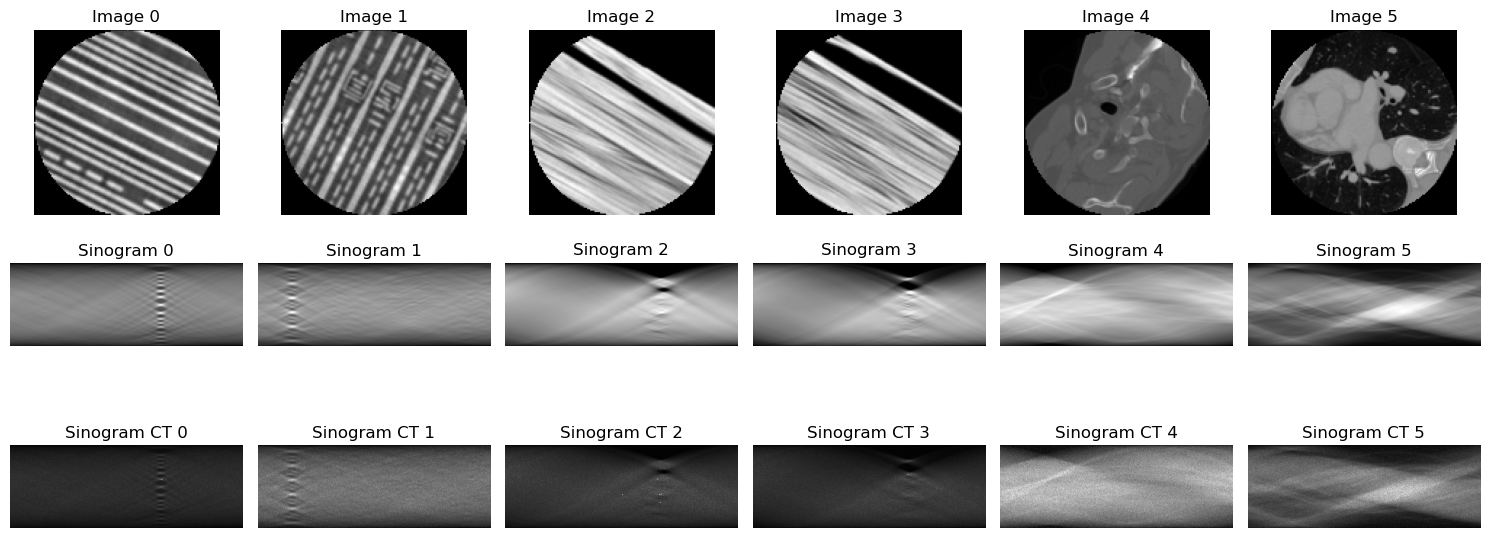

In [15]:
num_angles = 360
angles = linspace(0, 180, num_angles, endpoint=False)

sinogram = compute_sinogram(images, angles)

allocation, angles = uniform_allocation(num_angles=num_angles, device=device, exposure=1e5)
measurements = forward_ct(images, angles, exposure=allocation)
measurements_sinogram = sinogram_ct(measurements, allocation)
experiment = Experiment(allocation, measurements, angles)


fig, axes = plt.subplots(3, 6, figsize=(15, 6))
for i in range(6):
    print(f"min/max of image {i}: {images[i].min().item()}/{images[i].max().item()}")
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(sinogram[i].cpu().squeeze().T, cmap='gray')
    axes[1, i].set_title(f'Sinogram {i}')
    axes[1, i].axis('off')

    axes[2, i].imshow(measurements_sinogram[i].cpu().squeeze().T, cmap='gray')
    axes[2, i].set_title(f'Sinogram CT {i}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

sample 0: PSNR=25.326698303222656, min/max of FBP sample 0: 0.0/1.0
sample 1: PSNR=28.047039031982422, min/max of FBP sample 1: 0.0/0.9609305262565613
sample 2: PSNR=25.6828670501709, min/max of FBP sample 2: 0.0/1.0
sample 3: PSNR=25.155330657958984, min/max of FBP sample 3: 0.0/1.0
sample 4: PSNR=32.759681701660156, min/max of FBP sample 4: 0.0/0.9426011443138123
sample 5: PSNR=28.68244171142578, min/max of FBP sample 5: 0.0/0.9143691062927246


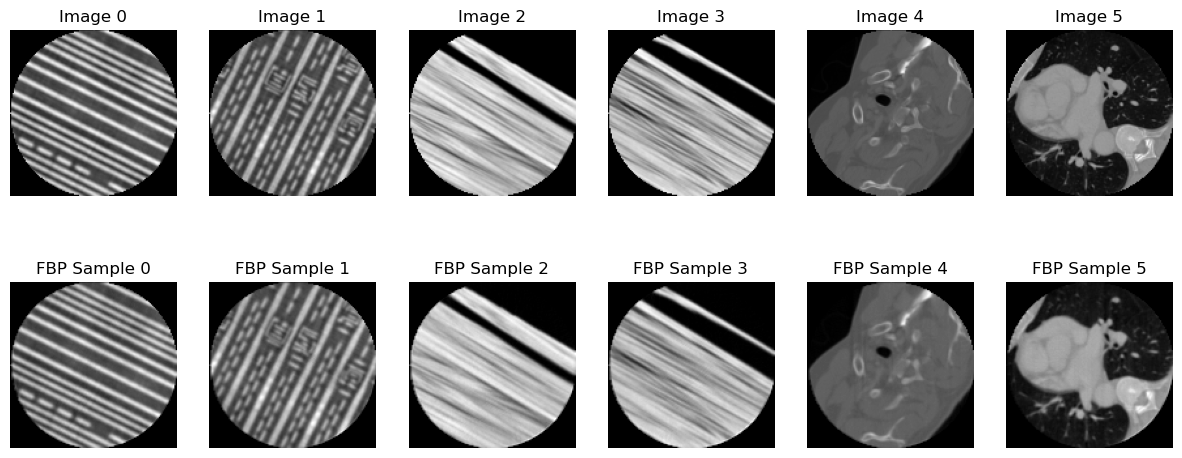

In [16]:
num_angles = 360
angles = linspace(0, 180, num_angles, endpoint=False)

sinogram = compute_sinogram(images, angles)

allocation, angles = uniform_allocation(num_angles=num_angles, device=device, exposure=1e8)
measurements = forward_ct(images, angles, exposure=allocation)
measurements_sinogram = sinogram_ct(measurements, allocation)
experiment = Experiment(allocation, measurements, angles)


class FBPModel:
    def __init__(self, experiment, weighted=True):
        self.experiment = experiment
        self.weighted = weighted
    
    def sample(self):
        return fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.allocation, weighted=self.weighted)
    
fbp_model = FBPModel(experiment)

samples = fbp_model.sample()
samples.shape

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(6):
    metrics = get_metrics(samples[i].squeeze(), images[i])
    print(f"sample {i}: PSNR={metrics['PSNR']}, min/max of FBP sample {i}: {samples[i].min().item()}/{samples[i].max().item()}")

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(samples[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'FBP Sample {i}')
    axes[1, i].axis('off')